In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import time

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import calendar
import matplotlib.patches as mpatches
import seaborn as sns

from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds



## ERA5 Rad


In [3]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)


#define na_mask as  all of 1.NA SPSS, 2.NA STSS, 3.NA STPS
#after Fay and McKinley 2014
#see https://github.com/RECCAP2-ocean/R2-shared-resources/blob/master/data/regions/README.md

npol_land = (masks.seamask == 0).where(masks.lat >=60)
nmidlat_land = (masks.seamask == 0).where((masks.lat <60) & (masks.lat >=20))
trop_land = (masks.seamask == 0).where((masks.lat <20) & (masks.lat >=-20))
smidlat_land = (masks.seamask == 0).where((masks.lat < -20) & (masks.lat >=-60))
spol_land = (masks.seamask == 0).where(masks.lat <-60)

land_mask = masks.seamask == 0

In [4]:
fp = '/data/jmex/ERA5/monthly/rad_forcing/era5_toa_global.nc'
ds = xr.open_dataset(fp).rename({'latitude': 'lat', 'longitude': 'lon', 'valid_time': 'time'}).drop_vars('expver')

#interpolate to masks grid
ds = ds.interp(lat=masks.lat, lon=masks.lon)


MemoryError: Unable to allocate 1.07 GiB for an array with shape (180, 794880) and data type float64

In [ ]:
ds = ds.where(land_mask)

In [10]:
weights = np.cos(np.deg2rad(land_mask.lat))


land_surface = land_mask.weighted(weights).sum()

In [12]:
#make sure all add up to one: 
npol_land.weighted(weights).sum()/land_surface + \
nmidlat_land.weighted(weights).sum()/land_surface + \
trop_land.weighted(weights).sum()/land_surface + \
smidlat_land.weighted(weights).sum()/land_surface + \
spol_land.weighted(weights).sum()/land_surface

<xarray.DataArray 'seamask' ()>
array(1.)

In [13]:
#take aso season only
t2m = t2m.where(t2m.time.dt.month.isin([8,9,10])).groupby('time.year').mean()


In [14]:
clim = t2m.sel(year = slice('1991', '2020')).mean('year')
t2m['anom'] = t2m.t2m - clim.t2m

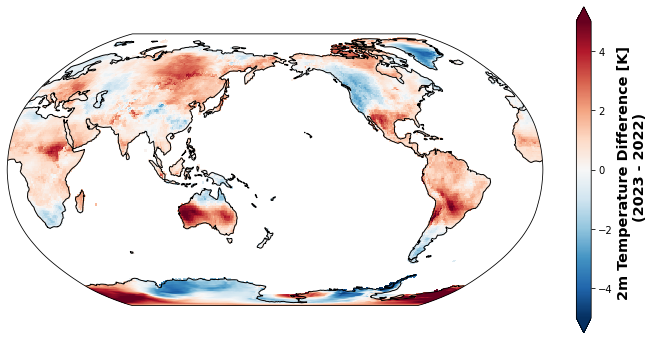

In [15]:
d =t2m.sel(year = 2023) - t2m.sel(year = 2022)

import cartopy.crs as ccrs


projection = ccrs.Robinson(central_longitude=180)
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=projection)
ax.coastlines()


d.t2m.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(), 
                      cmap='RdBu_r', vmin = -5, vmax = 5, cbar_kwargs={'label': '2m Temperature Difference [K] \n (2023 - 2022)'})

In [16]:
#compute all regional contributions
npol = t2m.where(npol_land).weighted(weights).mean(['lat', 'lon'])
npol = npol * npol_land.weighted(weights).sum()/land_surface

nmidlat = t2m.where(nmidlat_land).weighted(weights).mean(['lat', 'lon'])
nmidlat = nmidlat * nmidlat_land.weighted(weights).sum()/land_surface

trop = t2m.where(trop_land).weighted(weights).mean(['lat', 'lon'])
trop = trop * trop_land.weighted(weights).sum()/land_surface

smidlat = t2m.where(smidlat_land).weighted(weights).mean(['lat', 'lon'])
smidlat = smidlat * smidlat_land.weighted(weights).sum()/land_surface

spol = t2m.where(spol_land).weighted(weights).mean(['lat', 'lon'])
spol = spol * spol_land.weighted(weights).sum()/land_surface


In [ ]:
ls = [npol, nmidlat, trop, smidlat, spol][::-1]

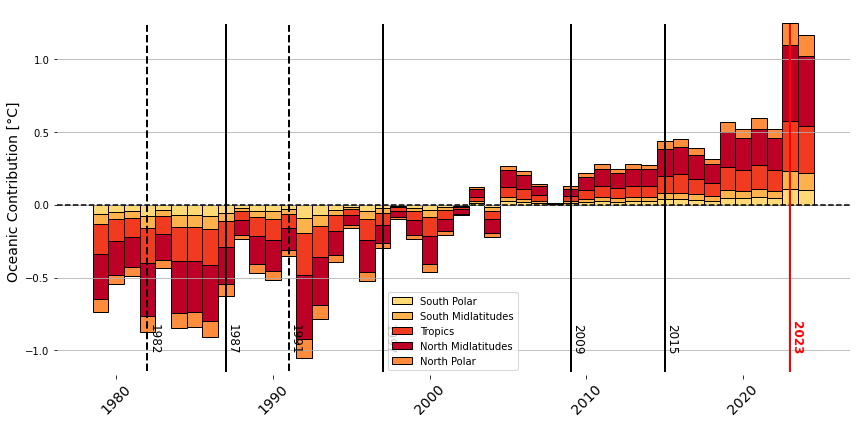

In [29]:
# make the plot
fig, ax = plt.subplots(1,1, figsize = (12,6))


labels = ['North Polar', 'North Midlatitudes', 'Tropics', 'South Midlatitudes', 'South Polar'][::-1]

colors = ['#fd8d3c',  '#bd0026', '#f03b20', '#feb24c', '#fed976'][::-1]



bottom_pos = np.zeros(len(npol['year']))
bottom_neg = np.zeros(len(npol['year']))

for i, r in enumerate(ls):
    values = r['anom'].values
    bottom = np.where(values>=0, bottom_pos, bottom_neg)
    ax.bar(r['year'].values, values, width=1,
           bottom=bottom, label=labels[i], color = colors[i], edgecolor = 'k')
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)

    
# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

#ax.scatter(sst.year.values, sst.anom.values, color = 'k', zorder = 20, s = 5)


# Add legend, labels, and title
ax.legend()
ax.set_ylabel('SST Anomaly Contributions [K]\n(1991-2020)')
ax.set_title('')
plt.xticks(rotation=45, fontweight = 'normal', size = 14)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines


ax.set_ylabel('Oceanic Contribution [°C]', fontsize = 14, fontweight = 'normal')

# Define the years of interest and their positions on the x-axis
years_of_interest = [1982, 1987, 1991, 1997, 2009, 2015, 2023]

for year in years_of_interest:
    if year == 2023:
        ax.annotate(str(year), (year, -1), rotation = 270, fontsize = 12, fontweight = 'bold', color = 'r')
    else:
        ax.annotate(str(year), (year, -1), rotation = 270, fontsize = 12)
    # Define rectangle parameters: (x, y) for bottom left corner, width, height
    if year in [1982, 1991]:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='--', color='k', linewidth=2)
    elif year == 2023:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='-', color='r', linewidth=2)
    else:
        ax.axvline(year, ymin = .01, ymax = .95, linestyle='-', color='k', linewidth=2)
    



'''
ax2 = ax.twinx()  # instantiate a second Axes that shares the same x-axis

ax2.set_ylabel('ONI', color='k', fontsize = 12)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor='k')
ax2.plot(oni.year,oni.oni9, marker = 'o', c = 'k', linestyle = '--')
#ax.legend()    

ax.set_ylim(-0.5,0.7)
ax2.set_ylim(-5/12 * 6,7/12 *6)
'''
for a in [ax]:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_visible(False)
    a.spines['bottom'].set_visible(False)

fig.tight_layout()

plt.show()


    

#ax.legend()

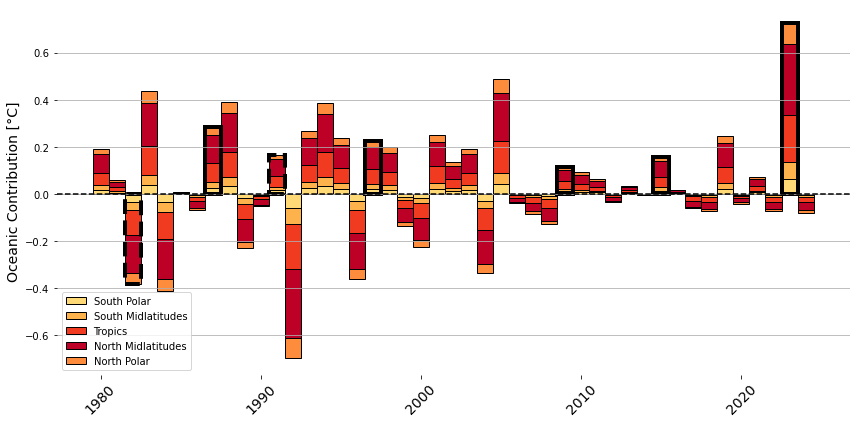

In [30]:
# make the plot
fig, ax = plt.subplots(1,1, figsize = (12,6))



bottom_pos = np.zeros(len(npol['year']))
bottom_neg = np.zeros(len(npol['year']))

for i, r in enumerate(ls):
    dr = r - r.shift(year=1)
    values = dr['anom'].values
    bottom = np.where(values>=0, bottom_pos, bottom_neg)
    ax.bar(r['year'].values, values, width=1,
           bottom=bottom, label=labels[i], color = colors[i], edgecolor = 'k')
    bottom_pos += np.where(values >= 0, values, 0)
    bottom_neg += np.where(values < 0, values, 0)

    
# Add a dashed line centered on zero
ax.axhline(0, color='black', linestyle='--')

#ax.scatter(sst.year.values, sst.anom.values, color = 'k', zorder = 20, s = 5)


# Add legend, labels, and title
ax.legend()
ax.set_ylabel('SST Anomaly Contributions [K]\n(1991-2020)')
ax.set_title('')
plt.xticks(rotation=45, fontweight = 'normal', size = 14)



# Only display horizontal grid lines and remove the plot frame
ax.yaxis.grid(True)  # Horizontal grid lines
ax.xaxis.grid(False)  # No vertical grid lines


ax.set_ylabel('Oceanic Contribution [°C]', fontsize = 14, fontweight = 'normal')


for year in years_of_interest:
    # Define rectangle parameters: (x, y) for bottom left corner, width, height
    y = bottom_neg[np.where(r.year.values == year)[0]]
    height = -bottom_neg[np.where(r.year.values == year)[0]]+bottom_pos[np.where(r.year.values == year)[0]]
    if year in [1982, 1991]:
        rect = plt.Rectangle((year-0.5, y), 1, height , linewidth=4, linestyle = '--', edgecolor='k', facecolor='none')
    else:
        rect = plt.Rectangle((year-0.5, y), 1, height , linewidth=4, linestyle='-', edgecolor='k', facecolor='none')

    # Add the rectangle to the plot
    ax.add_patch(rect)

'''
ax2 = ax.twinx()  # instantiate a second Axes that shares the same x-axis

ax2.set_ylabel('ONI', color='k', fontsize = 12)  # we already handled the x-label with ax1
ax2.tick_params(axis='y', labelcolor='k')
ax2.plot(oni.year,oni.oni9, marker = 'o', c = 'k', linestyle = '--')
#ax.legend()    

ax.set_ylim(-0.5,0.7)
ax2.set_ylim(-5/12 * 6,7/12 *6)
'''
for a in [ax]:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
    a.spines['left'].set_visible(False)
    a.spines['bottom'].set_visible(False)

fig.tight_layout()

plt.show()


    

#ax.legend()

In [24]:
l = [float((r-r.shift(year=1)).sel(year = 2023).anom.values) for r in ls]

In [25]:
l

[0.08857452877740025,
 0.30285509646988296,
 0.2006172954889199,
 0.07075434815939091,
 0.06284565576083037]

In [26]:
l[0]+l[2]

0.2891918242663202

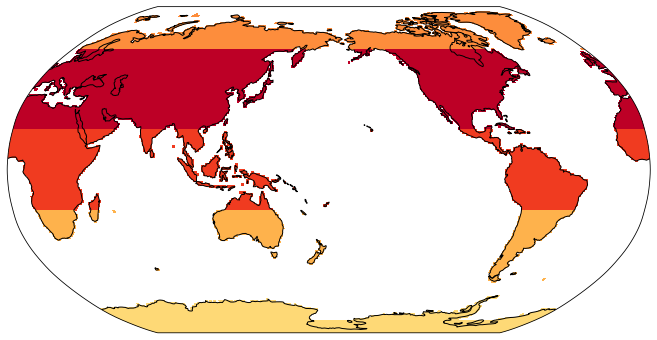

In [27]:
#make a plot in robinson projection of all the regional masks using the corect coloring
#plotting for the ind_mask, tropical_pacific_mask, extratropical_pacific_mask, southern_mask, sa_mask, na_mask, npol_mask


import cartopy.crs as ccrs

projection = ccrs.Robinson(central_longitude=180)
fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=projection)

masks_to_plot = {
    'North Polar': npol_land,
    'North Midlatitudes': nmidlat_land,
    'Tropics': trop_land,
    'South Midlatitudes': smidlat_land,
    'South Polar': spol_land
}

for (region, mask), color in zip(masks_to_plot.items(), colors):
    masked_data = mask.where(mask, other=np.nan)
    masked_data.plot.pcolormesh(ax=ax, transform=ccrs.PlateCarree(),
                               cmap=mcolors.ListedColormap([color]),
                               add_colorbar=False,
                               alpha=1)


ax.coastlines()
